# **Improving Customer Retention through Payment Analytics**

In the **Olist** ecosystem, some customers pay in a single installment, while others use up to 24. The goal is to **analyze if payment installments and payment type (Credit Card vs. Voucher/Boleto) affect Customer Satisfaction (Review Scores) and Delivery Speed**.

## Imports

In [188]:
import kagglehub
import pandas as pd
import numpy as np
from pathlib import Path
import dash
from dash import dcc, html, Input, Output, callback
import plotly.express as px
import plotly.graph_objects as go

## **Download DataSet**

In [189]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

DATA_DIR = Path(path)
print("Dataset downloaded to:", DATA_DIR)
print("\nFiles available:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name}")

Dataset downloaded to: C:\Users\laura\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2

Files available:
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


## **Data Strategy**

In [190]:
#Load individual tables

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv",
                     parse_dates=[
                         "order_purchase_timestamp",
                         "order_approved_at",
                         "order_delivered_carrier_date",
                         "order_delivered_customer_date",
                         "order_estimated_delivery_date"
                     ])
 
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
 
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv",
                      parse_dates=["review_creation_date", "review_answer_timestamp"])
 
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
 
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv",
                    parse_dates=["shipping_limit_date"])
 
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
 
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")
 
print("\nTable shapes:")
for name, df in [("orders", orders), ("payments", payments), ("reviews", reviews),
                 ("customers", customers), ("items", items), ("products", products),
                 ("category_translation", category_translation)]:
    print(f"  {name:25s} {df.shape}")


Table shapes:
  orders                    (99441, 8)
  payments                  (103886, 5)
  reviews                   (99224, 7)
  customers                 (99441, 5)
  items                     (112650, 7)
  products                  (32951, 9)
  category_translation      (71, 2)


### Handling Missing Values

In [191]:
# Orders with missing delivery date are the ones not yet delivered — expected
print(f"\nOrders total:               {len(orders):,}")
print(f"Delivered orders:           {orders['order_delivered_customer_date'].notna().sum():,}")
print(f"Unique customers:           {orders['customer_id'].nunique():,}")
 
# Payments: some orders have multiple payment rows (split payments)
print(f"\nPayment rows:               {len(payments):,}")
print(f"Unique orders in payments:  {payments['order_id'].nunique():,}")
print(f"Payment types:\n{payments['payment_type'].value_counts()}")


Orders total:               99,441
Delivered orders:           96,476
Unique customers:           99,441

Payment rows:               103,886
Unique orders in payments:  99,440
Payment types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


### Aggregate payments per order

- An order can be paid in multiple ways (e.g. voucher + credit card).
- Strategy: keep the dominant payment type (highest value), sum installments and total payment value across all payment rows for that order.

In [192]:
payments_agg = (
    payments
    .sort_values("payment_value", ascending=False)          # dominant type = highest value row
    .groupby("order_id")
    .agg(
        payment_type        = ("payment_type", "first"),    # dominant type
        payment_installments= ("payment_installments", "sum"),
        total_payment_value = ("payment_value", "sum"),
        n_payment_methods   = ("payment_type", "nunique")   # flag for split payments
    )
    .reset_index()
)
 
print(f"\nAggregated payment rows: {len(payments_agg):,}")
print(f"Split-payment orders:    {(payments_agg['n_payment_methods'] > 1).sum():,}")


Aggregated payment rows: 99,440
Split-payment orders:    2,246


### Aggregate items per order

In [193]:
# Translate product categories to English first
products_en = products.merge(category_translation, on="product_category_name", how="left")
 
items_agg = (
    items
    .merge(products_en[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .groupby("order_id")
    .agg(
        total_price         = ("price", "sum"),
        total_freight       = ("freight_value", "sum"),
        n_items             = ("order_item_id", "count"),
        product_category    = ("product_category_name_english", "first")  # primary category
    )
    .reset_index()
)
 
items_agg["total_order_value"] = items_agg["total_price"] + items_agg["total_freight"]
 
print(f"\nAggregated item rows: {len(items_agg):,}")


Aggregated item rows: 98,666


### Keep one review per order (most recent if duplicates exist)

In [194]:
reviews_clean = (
    reviews
    .sort_values("review_creation_date", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")
    [["order_id", "review_score", "review_creation_date"]]
)
 
print(f"\nReview rows (deduplicated): {len(reviews_clean):,}")


Review rows (deduplicated): 98,673


### Keep only delivered orders

In [195]:
# Delivery delta is only meaningful for orders that actually arrived
orders_delivered = orders[orders["order_status"] == "delivered"].copy()
print(f"\nDelivered orders: {len(orders_delivered):,}")


Delivered orders: 96,478


### Master join

In [196]:
df = (
    orders_delivered
    .merge(customers,     on="customer_id",  how="left")
    .merge(payments_agg,  on="order_id",     how="left")
    .merge(reviews_clean, on="order_id",     how="left")
    .merge(items_agg,     on="order_id",     how="left")
)
 
print(f"\nMaster dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Master dataframe shape: (96478, 23)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_type', 'payment_installments', 'total_payment_value', 'n_payment_methods', 'review_score', 'review_creation_date', 'total_price', 'total_freight', 'n_items', 'product_category', 'total_order_value']


### Check join quality

In [197]:
null_count = df.isnull().sum()
join_quality = (
    pd.DataFrame(
        {
            "column": null_count.index,
            "null_count": null_count.values,
            "null_pct": ((null_count / len(df)) * 100).round(2).values,
        }
    )
    .query("null_count > 0")
    .sort_values("null_pct", ascending=False)
)

print("\nColumns with nulls after join:")
print(join_quality.to_string(index=False))


Columns with nulls after join:
                       column  null_count  null_pct
             product_category        1351      1.40
                 review_score         646      0.67
         review_creation_date         646      0.67
            order_approved_at          14      0.01
order_delivered_customer_date           8      0.01
 order_delivered_carrier_date           2      0.00
          total_payment_value           1      0.00
         payment_installments           1      0.00
                 payment_type           1      0.00
            n_payment_methods           1      0.00


## **Feature Engineering**

### Delivery features

In [198]:
df["delivery_delta"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]
).dt.days
# Positive = delivered before estimate (early), negative = late
 
df["delivery_speed_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days
 
df["is_late"] = (df["delivery_delta"] < 0).astype(int)
 
print("Delivery features:")
print(f"  Avg delivery delta (days): {df['delivery_delta'].mean():.1f}")
print(f"  Late orders: {df['is_late'].sum():,} ({df['is_late'].mean()*100:.1f}%)")

Delivery features:
  Avg delivery delta (days): 10.9
  Late orders: 7,826 (8.1%)


### Customer lifetime orders

In [199]:
# Note: customer_id is unique per order in Olist (same person = new customer_id)
# Use customer_unique_id from the customers table to count real repeat buyers
customer_order_counts = (
    df.groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "customer_lifetime_orders"})
)
 
df = df.merge(customer_order_counts, on="customer_unique_id", how="left")
print(f"\nRepeat buyers (>1 order): {(df['customer_lifetime_orders'] > 1).sum():,}")


Repeat buyers (>1 order): 5,921


### One-hot encode payment type

In [200]:
payment_dummies = pd.get_dummies(df["payment_type"], prefix="payment")
df = pd.concat([df, payment_dummies], axis=1)
 
print(f"\nPayment dummy columns: {[c for c in df.columns if c.startswith('payment_')]}")


Payment dummy columns: ['payment_type', 'payment_installments', 'payment_boleto', 'payment_credit_card', 'payment_debit_card', 'payment_voucher']


### Binary satisfaction target

In [201]:
# Drop rows with no review score (orders without a review)
df = df.dropna(subset=["review_score"])
 
df["high_satisfaction"] = (df["review_score"] >= 4).astype(int)
 
print(f"\nSatisfaction split:")
print(df["high_satisfaction"].value_counts(normalize=True).round(3))


Satisfaction split:
high_satisfaction
1    0.789
0    0.211
Name: proportion, dtype: float64


### Final clean dataset

In [202]:
# Drop rows where key ML features are missing
ML_FEATURES = [
    "payment_installments", "total_price", "total_freight",
    "delivery_delta", "delivery_speed_days", "is_late",
    "total_order_value", "customer_lifetime_orders"
]
 
df_clean = df.dropna(subset=ML_FEATURES).copy()
 
print(f"\nFinal clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Dropped {len(df) - len(df_clean):,} rows with missing ML features")
 
# Quick preview
df_clean[[
    "order_id", "customer_state", "payment_type",
    "payment_installments", "total_order_value",
    "delivery_delta", "is_late", "review_score", "high_satisfaction"
]].head(5)


Final clean dataset: 95,823 rows × 32 columns
Dropped 9 rows with missing ML features


,order_id,customer_state,payment_type,payment_installments,total_order_value,delivery_delta,is_late,review_score,high_satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,SP,voucher,3.0,38.71,7.0,0,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,BA,boleto,1.0,141.46,5.0,0,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,GO,credit_card,3.0,179.12,17.0,0,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,credit_card,1.0,72.20,12.0,0,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,credit_card,1.0,28.62,9.0,0,5.0,1


## **EDA**

- dashboard.py  —  run with:  python dashboard.py
- then open http://127.0.0.1:8050 in your browser

In [203]:
# =============================================================================
# CONSTANTS & CONFIGURATION
# =============================================================================

COLOR_MAP = {
    "Credit card": "#185FA5", "Boleto": "#D85A30",
    "Voucher": "#1D9E75", "Debit card": "#7F77DD"
}

PAYMENT_LABELS = {
    "credit_card": "Credit card", "boleto": "Boleto",
    "voucher": "Voucher", "debit_card": "Debit card"
}

CHART_LAYOUT = dict(
    plot_bgcolor="white", paper_bgcolor="white",
    font_family="sans-serif", font_size=12,
    margin=dict(l=10, r=10, t=40, b=10),
)

BRAZIL_GEOJSON = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

# =============================================================================
# DATA LOADING
# =============================================================================

def load_and_clean_data():
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    DATA_DIR = Path(path)

    orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv",
                         parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"])
    payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
    reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
    customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
    items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
    products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
    cat_transl = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

    payments_agg = (
        payments.sort_values("payment_value", ascending=False)
        .groupby("order_id")
        .agg(payment_type=("payment_type","first"),
             payment_installments=("payment_installments","sum"),
             total_payment_value=("payment_value","sum"))
        .reset_index()
    )

    products_en = products.merge(cat_transl, on="product_category_name", how="left")
    items_agg = (
        items.merge(products_en[["product_id","product_category_name_english"]], on="product_id", how="left")
        .groupby("order_id")
        .agg(total_price=("price","sum"),
             total_freight=("freight_value","sum"),
             product_category=("product_category_name_english","first"))
        .reset_index()
    )
    items_agg["total_order_value"] = items_agg["total_price"] + items_agg["total_freight"]
    reviews_clean = reviews.sort_values("review_creation_date", ascending=False).drop_duplicates(subset="order_id", keep="first")[["order_id","review_score"]]

    df = (
        orders[orders["order_status"] == "delivered"]
        .merge(customers, on="customer_id", how="left")
        .merge(payments_agg, on="order_id", how="left")
        .merge(reviews_clean, on="order_id", how="left")
        .merge(items_agg, on="order_id", how="left")
    )

    df["delivery_delta"] = (df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]).dt.days
    df["delivery_speed_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
    df["is_late"] = (df["delivery_delta"] < 0).astype(int)
    df["payment_label"] = df["payment_type"].map(PAYMENT_LABELS).fillna("Other")
    df["year"] = df["order_purchase_timestamp"].dt.year
    df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
    
    # Customer Lifetime orders
    counts = df.groupby("customer_unique_id")["order_id"].count().reset_index().rename(columns={"order_id": "customer_lifetime_orders"})
    df = df.merge(counts, on="customer_unique_id", how="left")

    return df.dropna(subset=["payment_installments", "total_order_value", "review_score"])

df_clean = load_and_clean_data()
ALL_STATES = sorted(df_clean["customer_state"].unique())
ALL_YEARS = sorted(df_clean["year"].unique().astype(int))
ALL_PAYMENT_TYPES = [p for p in ["Credit card","Boleto","Voucher","Debit card"] if p in df_clean["payment_label"].unique()]

# =============================================================================
# UI COMPONENTS
# =============================================================================

def card(label, value, sub=""):
    return html.Div(style={"background":"white","borderRadius":"8px","padding":"15px","border":"0.5px solid #e8e8e8","flex":"1"}, children=[
        html.Div(label, style={"fontSize":"11px","color":"#888","textTransform":"uppercase"}),
        html.Div(value, style={"fontSize":"20px","fontWeight":"bold"}),
        html.Div(sub, style={"fontSize":"10px","color":"#aaa"})
    ])

def chart_card(figure, span_full=False):
    style = {"background":"white","borderRadius":"8px","border":"0.5px solid #e8e8e8","padding":"10px","marginBottom":"15px","width":"100%","boxSizing":"border-box"}
    if span_full: style["gridColumn"] = "1 / -1"
    return html.Div(style=style, children=[dcc.Graph(figure=figure, config={"displayModeBar":False, "responsive":True})])

# =============================================================================
# LAYOUT
# =============================================================================

app = dash.Dash(__name__, title="Olist Pro")

app.layout = html.Div(style={"fontFamily":"sans-serif","background":"#f4f4f2","minHeight":"100vh","paddingBottom":"30px"}, children=[
    
    # Header & Responsive Filters
    html.Div(style={"background":"white","padding":"15px 25px","display":"flex","flexWrap":"wrap","gap":"20px","alignItems":"center","borderBottom":"1px solid #ddd"}, children=[
        html.H3("Olist BI Dashboard", style={"margin":"0","fontSize":"18px","flex":"1"}),
        
        html.Div([html.Div("States", style={"fontSize":"10px"}), dcc.Dropdown(id="f-state", options=[{"label": s, "value": s} for s in ALL_STATES], multi=True, style={"minWidth":"200px"})]),
        html.Div([html.Div("Payment", style={"fontSize":"10px"}), dcc.Checklist(id="f-pay", options=[{"label": f" {p}", "value": p} for p in ALL_PAYMENT_TYPES], value=ALL_PAYMENT_TYPES, inline=True)]),
        html.Div([html.Div("Year", style={"fontSize":"10px"}), dcc.Checklist(id="f-year", options=[{"label": f" {y}", "value": y} for y in ALL_YEARS], value=ALL_YEARS, inline=True)]),
    ]),

    # KPI Row
    html.Div(id="kpi-row", style={"display":"flex","gap":"15px","padding":"20px 25px"}),

    dcc.Tabs(id="tabs", value="tab-overview", style={"padding":"0 25px"}, children=[
        dcc.Tab(label="Overview", value="tab-overview"),
        dcc.Tab(label="Payment Behavior", value="tab-payment"),
        dcc.Tab(label="Delivery & Satisfaction", value="tab-delivery"),
        dcc.Tab(label="Trends", value="tab-trends"),
    ]),

    # The Grid
    html.Div(id="tab-content", style={"display":"grid","gridTemplateColumns":"1fr 1fr","gap":"15px","padding":"20px 25px"})
])

# =============================================================================
# CALLBACK
# =============================================================================

@callback(
    Output("kpi-row", "children"),
    Output("tab-content", "children"),
    Input("f-state", "value"), Input("f-pay", "value"), Input("f-year", "value"), Input("tabs", "value")
)
def update_dashboard(selected_states, payment_types, years, tab):
    # 1. Filter
    d = df_clean.copy()
    if selected_states: d = d[d["customer_state"].isin(selected_states)]
    if payment_types: d = d[d["payment_label"].isin(payment_types)]
    if years: d = d[d["year"].isin(years)]

    if d.empty: return [], [html.Div("No data matches filters.", style={"gridColumn":"1/-1","textAlign":"center"})]

    # 2. KPIs
    kpis = [
        card("Orders", f"{len(d):,}"),
        card("Avg Score", f"{d['review_score'].mean():.2f}"),
        card("Avg Delivery Delay", f"{d['delivery_delta'].mean():.1f} days"),
        card("Late Orders", f"{d['is_late'].mean()*100:.1f}%")
    ]

    lo = {k: v for k, v in CHART_LAYOUT.items()}

    if tab == "tab-overview":
        # median installments by category
        cat = d.dropna(subset=["product_category"]).groupby("product_category")["payment_installments"].median().reset_index().sort_values("payment_installments", ascending=False).head(10)
        figA = px.bar(cat, x="payment_installments", y="product_category", orientation="h", title="Top 10 Categories by Median Installments", color_discrete_sequence=["#185FA5"])
        figA.update_layout({**lo, "height": 350, "yaxis": {"categoryorder": "total ascending"}})

        # Payment share by state
        pbs = d.groupby(["customer_state","payment_label"]).size().reset_index(name="c")
        pbs["share"] = (pbs["c"] / pbs.groupby("customer_state")["c"].transform("sum") * 100)
        figB = px.bar(pbs, x="customer_state", y="share", color="payment_label", color_discrete_map=COLOR_MAP, title="Payment Method Share by State")
        figB.update_layout({**lo, "height": 350, "barmode": "stack", "xaxis_tickangle": -45})
        
        return kpis, [chart_card(figA, span_full=True), chart_card(figB, span_full=True)]

    elif tab == "tab-payment":
        # Histogram
        figA = px.histogram(d, x="payment_installments", title="Installment Distribution", color_discrete_sequence=["#185FA5"])
        figA.update_layout({**lo, "height": 300})

        # Correlation (FULL ITEMS RESTORED)
        corr_cols = ["payment_installments", "total_order_value", "total_freight", "delivery_delta", "delivery_speed_days", "is_late", "review_score", "customer_lifetime_orders"]
        cm = d[corr_cols].corr().round(2)
        mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
        cm_masked = cm.where(~mask)
        figB = px.imshow(cm_masked, text_auto=True, color_continuous_scale="RdBu", zmin=-1, zmax=1, title="Correlation Matrix (Lower Triangle)")
        figB.update_layout({**lo, "height": 450})

        return kpis, [chart_card(figA, span_full=True), chart_card(figB, span_full=True)]

    elif tab == "tab-delivery":
        # Brazil Map
        map_all = df_clean.groupby("customer_state").agg(t=("order_id","count"), l=("is_late","sum")).reset_index()
        map_all["late_rate"] = (map_all["l"] / map_all["t"]) * 100
        if selected_states:
            map_all["display"] = map_all.apply(lambda x: x["late_rate"] if x["customer_state"] in selected_states else None, axis=1)
        else:
            map_all["display"] = map_all["late_rate"]

        fig_map = px.choropleth(map_all, geojson=BRAZIL_GEOJSON, locations="customer_state", featureidkey="properties.sigla",
                                color="display", color_continuous_scale="Reds", title="Late Delivery % by State")
        fig_map.update_geos(fitbounds="locations", visible=False)
        fig_map.update_layout({**lo, "height": 450})

        # Violin
        figV = go.Figure()
        for pt, color in COLOR_MAP.items():
            subset = d[d["payment_label"] == pt]
            if not subset.empty:
                figV.add_trace(go.Violin(x=subset["payment_label"], y=subset["review_score"], name=pt, line_color=color, points=False, box_visible=True))
        figV.update_layout({**lo, "title": "Review Score by Payment Type", "height": 350, "showlegend": False})

        # Box
        figBox = px.box(d, x="payment_label", y="delivery_delta", color="payment_label", color_discrete_map=COLOR_MAP, title="Delivery Delta (vs Estimate)")
        figBox.update_layout({**lo, "height": 350, "showlegend": False})

        # Late Bar
        late_st = d.groupby("customer_state")["is_late"].mean().reset_index().sort_values("is_late", ascending=False)
        figBar = px.bar(late_st, x="customer_state", y="is_late", title="Late Rate by Selected States", color="is_late", color_continuous_scale="Reds")
        figBar.update_layout({**lo, "height": 350, "coloraxis_showscale": False})

        return kpis, [chart_card(fig_map, span_full=True), chart_card(figV), chart_card(figBox), chart_card(figBar, span_full=True)]

    else: # Trends
        trend = d.groupby(["year_month","payment_label"])["review_score"].mean().reset_index()
        figA = px.line(trend, x="year_month", y="review_score", color="payment_label", color_discrete_map=COLOR_MAP, title="Avg Review Score Trend")
        figA.update_layout({**lo, "height": 400, "xaxis_tickangle": -45})
        return kpis, [chart_card(figA, span_full=True)]

if __name__ == "__main__":
    app.run(debug=True, port=8050)

## **Machine Learning**

### Feature Engineering & Target Setting

In [204]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

# Make project imports work regardless of whether notebook cwd is project root or notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import get_numeric_feature_set, run_full_ml_workflow, plot_shap_summary

# Optional sanity check so downstream cells fail fast with a clear message
if not isinstance(df_clean, pd.DataFrame):
    raise ValueError("df_clean is not ready. Run the data preparation cells first.")

### src-Powered ML Workflow (Training, Metrics, and ROC)

In [205]:
# Use the reusable src workflow instead of re-implementing training logic in-notebook
numeric_features = get_numeric_feature_set(feature_scope="post_delivery")

ml_results = run_full_ml_workflow(
    df=df_clean,
    numeric_features=numeric_features,
    feature_scope="post_delivery",
    n_clusters=4,
    compute_shap=True,
    random_state=42,
)

print("--- Model Metrics (sorted by low-satisfaction performance) ---")
display(ml_results["metrics"])

print("\n--- Top At-Risk Orders/Customers ---")
display(
    ml_results["risk_table"][
        [
            "scoring_model",
            "predicted_risk_band",
            "predicted_low_probability",
            "predicted_high_probability",
            "decision_threshold",
        ]
    ].head(10)
)

if ml_results["roc_figure"] is not None:
    ml_results["roc_figure"].show()

--- Model Metrics (sorted by low-satisfaction performance) ---


,model,decision_threshold,validation_f1_low_satisfaction,validation_recall_low_satisfaction,f1_high_satisfaction,f1_low_satisfaction,f1_macro,precision_low_satisfaction,recall_low_satisfaction,roc_auc
0,XGBoost,0.79,0.416348,0.455728,0.826927,0.421613,0.624270,0.388437,0.460986,0.677884
1,Logistic Regression,0.53,0.408657,0.417957,0.835184,0.407243,0.621213,0.394700,0.420609,0.662895
2,Random Forest,0.58,0.394867,0.419195,0.826065,0.405944,0.616004,0.379414,0.436463,0.666566



--- Top At-Risk Orders/Customers ---


,scoring_model,predicted_risk_band,predicted_low_probability,predicted_high_probability,decision_threshold
0,XGBoost,high,0.981112,0.018888,0.79
1,XGBoost,high,0.980055,0.019945,0.79
2,XGBoost,high,0.979795,0.020205,0.79
3,XGBoost,high,0.977100,0.022900,0.79
4,XGBoost,high,0.976697,0.023303,0.79
5,XGBoost,high,0.975325,0.024675,0.79
6,XGBoost,high,0.975071,0.024929,0.79
7,XGBoost,high,0.974542,0.025458,0.79
8,XGBoost,high,0.974419,0.025581,0.79
9,XGBoost,high,0.974101,0.025899,0.79


### Model Explainability with SHAP (via src)

Generating SHAP Summary Plot...


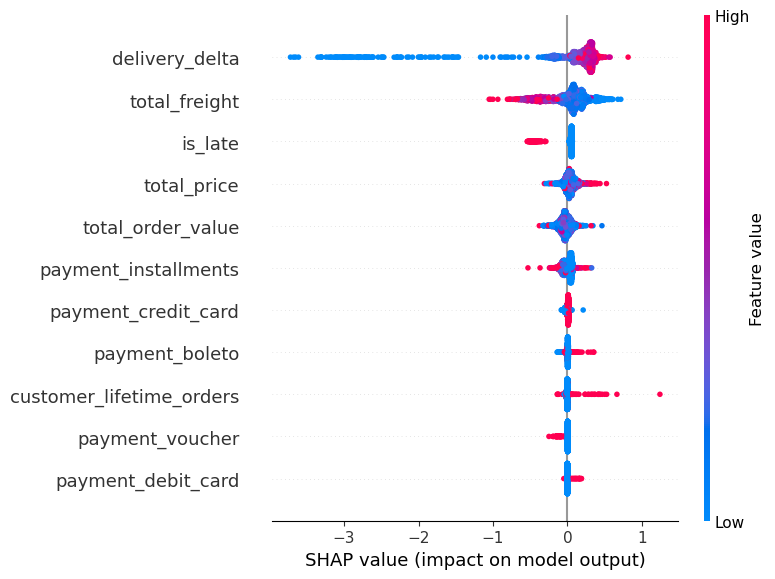

In [206]:
print("Generating SHAP Summary Plot...")

if ml_results.get("shap") is None:
    print("SHAP artifacts were not computed. Set compute_shap=True in the workflow cell.")
else:
    _ = plot_shap_summary(ml_results["shap"], max_display=12, plot_type="dot")

### Customer Segmentation and Risk Bands (via src)

In [207]:
print("--- Segment Profile ---")
display(ml_results["segment_profile"])

if ml_results["segment_figure"] is not None:
    ml_results["segment_figure"].show()

print("\n--- Risk Distribution by Band ---")
risk_distribution = (
    ml_results["risk_table"]["predicted_risk_band"]
    .value_counts(dropna=False)
    .rename_axis("predicted_risk_band")
    .reset_index(name="count")
)
display(risk_distribution)

--- Segment Profile ---


,segment,orders,payment_installments,total_order_value,delivery_delta,delivery_speed_days,is_late,customer_lifetime_orders,high_satisfaction,average_review_score,segment_label
0,3,67864,1.902555,114.384690,12.448603,10.213471,0.000000,1.000000,0.832577,4.307895,budget
1,2,14976,7.739116,370.038553,13.699119,11.335136,0.001402,1.008480,0.805222,4.218216,high-value | installment-heavy | reliably deli...
2,1,7604,3.020121,167.210914,-9.793004,30.989742,0.999737,1.049316,0.344424,2.560231,late-delivery risk | satisfaction risk
3,0,5379,3.191857,132.749433,13.063209,10.469418,0.006879,2.253765,0.828593,4.320134,budget | reliably delivered | repeat buyers



--- Risk Distribution by Band ---


,predicted_risk_band,count
0,low,89958
1,high,4358
2,medium,1507


In [208]:
print("--- Business Recommendations ---")

risk_counts = ml_results["risk_table"]["predicted_risk_band"].value_counts()
top_band = risk_counts.index[0]
top_band_count = int(risk_counts.iloc[0])
total_orders = int(risk_counts.sum())
top_band_pct = (top_band_count / total_orders) * 100

segment_profile = ml_results["segment_profile"].copy()
segment_profile["low_satisfaction_rate"] = 1 - segment_profile["high_satisfaction"]
priority_segment = segment_profile.sort_values(
    ["low_satisfaction_rate", "orders"],
    ascending=[False, False],
).iloc[0]

print(
    f"1) Primary risk concentration: '{top_band}' band with {top_band_count:,} orders "
    f"({top_band_pct:.1f}% of scored population)."
)
print(
    "2) Priority segment for retention actions: "
    f"segment {int(priority_segment['segment'])} ({priority_segment['segment_label']}) "
    f"with low-satisfaction rate of {priority_segment['low_satisfaction_rate']*100:.1f}% "
    f"across {int(priority_segment['orders']):,} orders."
)
print(
    "3) Suggested playbook: apply strongest incentives and proactive service outreach to high-risk "
    "orders in the priority segment; use lighter nudges for medium-risk orders."
)

--- Business Recommendations ---
1) Primary risk concentration: 'low' band with 89,958 orders (93.9% of scored population).
2) Priority segment for retention actions: segment 1 (late-delivery risk | satisfaction risk) with low-satisfaction rate of 65.6% across 7,604 orders.
3) Suggested playbook: apply strongest incentives and proactive service outreach to high-risk orders in the priority segment; use lighter nudges for medium-risk orders.


### Operational Validation: Cost, Geography, and Targeted Intervention

In [209]:
# -----------------------------------------------------------------------------
# 1) Cost-Benefit: Cost of False Negatives (actual low satisfaction predicted as high)
# -----------------------------------------------------------------------------
risk_table = ml_results["risk_table"].copy()
clustered_data = ml_results["segmentation"]["clustered_data"].copy()
segment_profile = ml_results["segment_profile"].copy()

join_key = "order_id" if "order_id" in risk_table.columns and "order_id" in clustered_data.columns else None
if join_key is None:
    raise ValueError("Could not find a common key (order_id) to join risk and segment outputs.")

# clustered_data stores segment id; labels are in segment_profile
segment_lookup = clustered_data[[join_key, "segment"]].drop_duplicates(subset=[join_key])
segment_labels = segment_profile[["segment", "segment_label"]].drop_duplicates(subset=["segment"])
segment_lookup = segment_lookup.merge(segment_labels, on="segment", how="left")
risk_enriched = risk_table.merge(segment_lookup, on=join_key, how="left")

false_negative_mask = (
    (risk_enriched["high_satisfaction"] == 0)
    & (risk_enriched["predicted_high_satisfaction"] == 1)
)
false_negative_orders = risk_enriched[false_negative_mask].copy()

fn_cost_by_segment = (
    false_negative_orders.groupby(["segment", "segment_label"], dropna=False)
    .agg(
        false_negative_orders=(join_key, "count"),
        estimated_lost_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean"),
    )
    .sort_values("estimated_lost_revenue", ascending=False)
    .reset_index()
)

print("--- Cost of False Negatives by Segment ---")
display(fn_cost_by_segment.head(5))

# -----------------------------------------------------------------------------
# 2) State-Level Sentiment: Is the late-delivery-risk segment geographically concentrated?
# -----------------------------------------------------------------------------
late_risk_match = segment_profile["segment_label"].str.contains("late-delivery risk", case=False, na=False)
if late_risk_match.any():
    late_segment_id = int(segment_profile.loc[late_risk_match, "segment"].iloc[0])
else:
    # Fallback: segment with highest observed late rate
    late_segment_id = int(segment_profile.sort_values("is_late", ascending=False).iloc[0]["segment"])

clustered_geo = clustered_data.copy()
clustered_geo["is_late_segment"] = (clustered_geo["segment"] == late_segment_id).astype(int)
overall_late_segment_share = clustered_geo["is_late_segment"].mean()

state_late_summary = (
    clustered_geo.groupby("customer_state", dropna=False)
    .agg(
        orders=(join_key, "count"),
        late_segment_orders=("is_late_segment", "sum"),
    )
    .reset_index()
)
state_late_summary["late_segment_share"] = state_late_summary["late_segment_orders"] / state_late_summary["orders"]
state_late_summary["late_segment_lift_vs_overall"] = (
    state_late_summary["late_segment_share"] / overall_late_segment_share
)
state_late_summary = state_late_summary.sort_values(
    ["late_segment_lift_vs_overall", "late_segment_orders"],
    ascending=[False, False],
)

print(f"\n--- State Concentration for Late-Delivery Segment (segment={late_segment_id}) ---")
print(f"Overall share of this segment: {overall_late_segment_share*100:.2f}%")
display(state_late_summary.head(5))

# -----------------------------------------------------------------------------
# 3) Proactive Intervention: delayed-shipping email only for High Risk band
# -----------------------------------------------------------------------------
intervention_candidates = risk_enriched[
    (risk_enriched["predicted_risk_band"] == "high")
    & (
        ((risk_enriched["is_late"] == 1) if "is_late" in risk_enriched.columns else False)
        | ((risk_enriched["delivery_delta"] < 0) if "delivery_delta" in risk_enriched.columns else False)
    )
].copy()

population_size = len(risk_enriched)
candidate_size = len(intervention_candidates)
candidate_pct = (candidate_size / population_size * 100) if population_size else 0.0

print("\n--- Delayed-Shipping High-Risk Intervention Pool ---")
print(
    f"Candidates: {candidate_size:,} / {population_size:,} orders "
    f"({candidate_pct:.2f}% of scored orders)"
)

preview_columns = [
    col for col in [
        "order_id",
        "customer_unique_id",
        "customer_state",
        "payment_type",
        "total_order_value",
        "delivery_delta",
        "predicted_low_probability",
        "predicted_risk_band",
        "segment",
        "segment_label",
    ]
    if col in intervention_candidates.columns
]

display(
    intervention_candidates[preview_columns]
    .sort_values("predicted_low_probability", ascending=False)
    .head(5)
)

# Optional: create a compact message payload table for downstream email automation
intervention_payload = intervention_candidates[[
    col for col in [
        "order_id",
        "customer_unique_id",
        "customer_state",
        "payment_type",
        "total_order_value",
        "delivery_delta",
        "predicted_low_probability",
    ]
    if col in intervention_candidates.columns
]].copy()

if "delivery_delta" in intervention_payload.columns:
    intervention_payload["delay_days"] = intervention_payload["delivery_delta"].abs().round(0).astype(int)

if "predicted_low_probability" in intervention_payload.columns:
    intervention_payload["risk_pct"] = (intervention_payload["predicted_low_probability"] * 100).round(1)

print("\nPrepared intervention_payload for export/automation.")

--- Cost of False Negatives by Segment ---


,segment,segment_label,false_negative_orders,estimated_lost_revenue,avg_order_value
0,3,budget,8193,855469.47,104.414680
1,2,high-value | installment-heavy | reliably deli...,1441,465770.48,323.227259
2,0,budget | reliably delivered | repeat buyers,584,67514.48,115.606986
3,1,late-delivery risk | satisfaction risk,32,2722.43,85.075937



--- State Concentration for Late-Delivery Segment (segment=1) ---
Overall share of this segment: 7.94%


,customer_state,orders,late_segment_orders,late_segment_share,late_segment_lift_vs_overall
1,AL,394,92,0.233503,2.942519
9,MA,712,134,0.188202,2.371660
16,PI,471,75,0.159236,2.006633
5,CE,1273,195,0.153181,1.930340
24,SE,334,50,0.149701,1.886476



--- Delayed-Shipping High-Risk Intervention Pool ---
Candidates: 4,358 / 95,823 orders (4.55% of scored orders)


,order_id,customer_unique_id,customer_state,payment_type,total_order_value,delivery_delta,predicted_low_probability,predicted_risk_band,segment,segment_label
0,74ad3397d84521ee94f326aad1a35d14,207abcf5e65e72037f216db0540406e4,RJ,boleto,189.51,-31.0,0.981112,high,1,late-delivery risk | satisfaction risk
1,21adb757aaef1f7f6240352b33d30e5a,7a41a033d1171fe68f363c2a2c16d448,RN,boleto,206.57,-27.0,0.980055,high,1,late-delivery risk | satisfaction risk
2,45b0a671da62d1c868294b22b4837dca,fe612e4c139f4350d17f1b9f5cbbe3f0,RJ,credit_card,189.37,-28.0,0.979795,high,1,late-delivery risk | satisfaction risk
3,942e1205a3ca6fd0147718ac16f4bb54,623d392cefd1e9b743242b556b6bb0ef,RJ,boleto,193.19,-29.0,0.977100,high,1,late-delivery risk | satisfaction risk
4,9d3c48c87bfb7e8b574b4d375f882841,93f4d868403d413b5bbbe193cbfef981,MG,credit_card,188.40,-34.0,0.976697,high,1,late-delivery risk | satisfaction risk



Prepared intervention_payload for export/automation.


### VIP-Weighted Retraining (Sample Weight for High-Value Segment)

In [210]:
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

weighted_artifacts = model_utils.train_vip_weighted_xgboost(
    training=ml_results["training"],
    risk_enriched=risk_enriched,
    segment_profile=segment_profile,
    vip_weight=2.0,
    low_satisfaction_weight=1.0,
    random_state=42,
)

print(f"VIP segment used for weighting: {weighted_artifacts['vip_segment_id']}")
display(weighted_artifacts["summary"])
print(
    "VIP false-negative revenue (lower is better) | "
    f"baseline: {weighted_artifacts['fn_revenue_baseline']:,.2f} "
    f"vs weighted: {weighted_artifacts['fn_revenue_weighted']:,.2f}"
)

VIP segment used for weighting: 2


,model_variant,decision_threshold,f1_low_satisfaction,recall_low_satisfaction,precision_low_satisfaction,roc_auc
0,Baseline XGBoost,0.79,0.421613,0.460986,0.388437,0.677884
1,VIP-weighted XGBoost,0.69,0.421789,0.485261,0.373001,0.680002


VIP false-negative revenue (lower is better) | baseline: 126,369.57 vs weighted: 120,304.93


### Revenue at Risk Map: High-Value Segment with Late Deliveries

In [211]:
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

# Focus on the most expensive segment and only late deliveries
vip_segment_id = weighted_artifacts["vip_segment_id"] if "weighted_artifacts" in globals() else int(segment_profile.sort_values("total_order_value", ascending=False).iloc[0]["segment"])

rev_risk_state = model_utils.build_revenue_at_risk_table(
    risk_enriched=risk_enriched,
    vip_segment_id=vip_segment_id,
)

print("--- Revenue at Risk by State (VIP + Late) ---")
display(rev_risk_state.head(5))

geojson_url = BRAZIL_GEOJSON if "BRAZIL_GEOJSON" in globals() else "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
fig_rev_risk = model_utils.build_revenue_at_risk_map(
    revenue_at_risk_table=rev_risk_state,
    geojson_url=geojson_url,
)
fig_rev_risk.show()

--- Revenue at Risk by State (VIP + Late) ---


,customer_state,vip_late_orders,revenue_at_risk,avg_order_value
0,SP,11,19857.53,1805.230000
1,RJ,6,7910.08,1318.346667
2,MA,1,2338.48,2338.480000
3,GO,1,2115.79,2115.790000
4,PR,1,1843.85,1843.850000


### Export Intervention Payload for Email Agent (with Personalization Metadata)

In [212]:
from pathlib import Path
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

export_path = Path("outputs") / "intervention" / "intervention_payload_high_risk_late.csv"
export_result = model_utils.prepare_intervention_payload(
    intervention_candidates=intervention_candidates,
    output_path=export_path,
)

agent_payload = export_result["payload"]

print(f"Exported: {export_result['exported_to']}")
print(f"Rows: {len(agent_payload):,}")
display(agent_payload.head(5))

Exported: outputs\intervention\intervention_payload_high_risk_late.csv
Rows: 4,358


,order_id,customer_unique_id,customer_state,payment_type,payment_installments,product_category,total_order_value,total_price,total_freight,delivery_delta,...,predicted_high_probability,predicted_risk_band,segment,segment_label,delay_days,risk_pct,value_tier,recommended_coupon_pct,campaign_reason,apology_style
0,74ad3397d84521ee94f326aad1a35d14,207abcf5e65e72037f216db0540406e4,RJ,boleto,1.0,furniture_decor,189.51,140.00,49.51,-31.0,...,0.018888,high,1,late-delivery risk | satisfaction risk,31,98.099998,high,25,late_delivery_high_risk,white_glove
1,21adb757aaef1f7f6240352b33d30e5a,7a41a033d1171fe68f363c2a2c16d448,RN,boleto,1.0,office_furniture,206.57,154.99,51.58,-27.0,...,0.019945,high,1,late-delivery risk | satisfaction risk,27,98.000000,high,25,late_delivery_high_risk,white_glove
2,45b0a671da62d1c868294b22b4837dca,fe612e4c139f4350d17f1b9f5cbbe3f0,RJ,credit_card,2.0,computers_accessories,189.37,149.00,40.37,-28.0,...,0.020205,high,1,late-delivery risk | satisfaction risk,28,98.000000,high,25,late_delivery_high_risk,white_glove
3,942e1205a3ca6fd0147718ac16f4bb54,623d392cefd1e9b743242b556b6bb0ef,RJ,boleto,1.0,office_furniture,193.19,149.94,43.25,-29.0,...,0.022900,high,1,late-delivery risk | satisfaction risk,29,97.699997,high,25,late_delivery_high_risk,white_glove
4,9d3c48c87bfb7e8b574b4d375f882841,93f4d868403d413b5bbbe193cbfef981,MG,credit_card,1.0,bed_bath_table,188.40,159.90,28.50,-34.0,...,0.023303,high,1,late-delivery risk | satisfaction risk,34,97.699997,high,25,late_delivery_high_risk,white_glove
